# Task
Generate dummy manufacturing BOM data where 25% of the total spend is initially 'Local', then simulate a strategic shift to reach 50% local spend by switching high-value international components (applying a +12% cost penalty and -7 day lead time benefit). Finally, create a dashboard visualizing the before/after impact and print a summary of the total cost variance and lead time reduction.

## Generate Dummy BOM Data

### Subtask:
Create a dummy manufacturing dataset where 25% of the total spend is initially 'Local'.


**Reasoning**:
Generate the dummy dataset as per the instructions, calculating the total spend and adjusting the 'Current_Origin' to achieve approximately 25% local spend.



In [1]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of components
n_components = 100

# Create dummy data
component_ids = [f'C-{i:03d}' for i in range(1, n_components + 1)]
categories = np.random.choice(['Electronics', 'Mechanics', 'Packaging', 'Software'], size=n_components)
annual_volumes = np.random.randint(100, 5001, size=n_components)
unit_costs = np.random.uniform(10.0, 1000.0, size=n_components)
lead_times = np.random.randint(14, 91, size=n_components)

# Create DataFrame
df = pd.DataFrame({
    'Component_ID': component_ids,
    'Category': categories,
    'Annual_Volume': annual_volumes,
    'Unit_Cost_SAR': unit_costs,
    'Lead_Time_Days': lead_times
})

# Calculate Total Spend
df['Total_Spend'] = df['Annual_Volume'] * df['Unit_Cost_SAR']

# Initialize Current_Origin
df['Current_Origin'] = 'International'

# Force 25% local spend
total_dataset_spend = df['Total_Spend'].sum()
target_local_spend = 0.25 * total_dataset_spend

# Shuffle df to randomly pick items to be local (without bias to cost/volume yet)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Calculate cumulative spend to find cutoff
df_shuffled['Cumulative_Spend'] = df_shuffled['Total_Spend'].cumsum()

# Find the index where cumulative spend crosses the target
cutoff_indices = df_shuffled.index[df_shuffled['Cumulative_Spend'] <= target_local_spend].tolist()

# If we have items that fit under the cap, set them to Local
if cutoff_indices:
    last_index = cutoff_indices[-1]
    # We might need one more to get closer to 25% if the first item > target or list is empty logic handles it.
    # Let's just take the items that sum up to <= target.
    # To be closer, we could check if adding the next one makes the error smaller, but strictly <= is fine for dummy data.
    local_component_ids = df_shuffled.loc[:last_index, 'Component_ID'].values
    df.loc[df['Component_ID'].isin(local_component_ids), 'Current_Origin'] = 'Local'

# Verify
actual_local_spend = df[df['Current_Origin'] == 'Local']['Total_Spend'].sum()
local_share = actual_local_spend / total_dataset_spend

print(f"Total Dataset Spend: {total_dataset_spend:,.2f} SAR")
print(f"Target Local Spend (25%): {target_local_spend:,.2f} SAR")
print(f"Actual Local Spend: {actual_local_spend:,.2f} SAR")
print(f"Actual Local Share: {local_share:.2%}")

df.head()

Total Dataset Spend: 123,014,639.60 SAR
Target Local Spend (25%): 30,753,659.90 SAR
Actual Local Spend: 29,652,338.98 SAR
Actual Local Share: 24.10%


,Component_ID,Category,Annual_Volume,Unit_Cost_SAR,Lead_Time_Days,Total_Spend,Current_Origin
0,C-001,Packaging,4898,46.518078,37,2.278455e+05,Local
1,C-002,Software,261,613.468691,59,1.601153e+05,International
2,C-003,Electronics,4397,507.652233,66,2.232147e+06,International
3,C-004,Packaging,2081,60.963964,73,1.268660e+05,International
4,C-005,Packaging,1095,285.860000,76,3.130167e+05,Local


## Run Localization Simulation

### Subtask:
Simulate the strategic shift to 50% local spend by identifying high-value international components to switch, applying specific cost and lead time adjustments.


**Reasoning**:
Perform the simulation to increase local spend to 50% by switching high-value international components, applying a 12% cost penalty and a 7-day lead time reduction.



In [2]:
import numpy as np

# 1. Calculate targets
total_spend = df['Total_Spend'].sum()
target_local_spend_50 = 0.50 * total_spend
current_local_spend = df[df['Current_Origin'] == 'Local']['Total_Spend'].sum()
spend_gap = target_local_spend_50 - current_local_spend

print(f"Total Spend: {total_spend:,.2f}")
print(f"Current Local Spend: {current_local_spend:,.2f}")
print(f"Target Local Spend (50%): {target_local_spend_50:,.2f}")
print(f"Gap to Fill: {spend_gap:,.2f}")

# 2. Identify candidates to switch (International, High Value)
# Filter for International items
international_df = df[df['Current_Origin'] == 'International'].copy()
# Sort by Total Spend descending to pick high value items first
international_df = international_df.sort_values(by='Total_Spend', ascending=False)

# Calculate cumulative spend of these candidates
international_df['Cumulative_Spend'] = international_df['Total_Spend'].cumsum()

# Find items needed to cross the gap
switch_candidates = international_df[international_df['Cumulative_Spend'] <= spend_gap]
# If the gap isn't perfectly met, we might need one more item to cross the threshold or get closest
# Let's take the index of the first item that exceeds the gap if the list is empty or short,
# but the instruction implies reaching *at least* or approximately 50%.
# Using <= gap ensures we are close, let's include the one that crosses the line to ensure we hit > 50% if possible.
last_idx = international_df[international_df['Cumulative_Spend'] > spend_gap].index[0] if not international_df[international_df['Cumulative_Spend'] > spend_gap].empty else None

switched_ids = switch_candidates['Component_ID'].tolist()
if last_idx and (international_df.loc[last_idx, 'Cumulative_Spend'] - spend_gap) < (spend_gap - switch_candidates['Total_Spend'].sum()):
   # Simple logic: just add the crossover item to ensure we reach the target volume
   switched_ids.append(international_df.loc[last_idx, 'Component_ID'])
elif last_idx and len(switched_ids) == 0:
    # If no single item was smaller than gap (gap is small, items are huge), take the first one
    switched_ids.append(international_df.loc[last_idx, 'Component_ID'])

# 3. Create Simulation Columns
df['Simulation_Status'] = 'Unchanged'
df.loc[df['Current_Origin'] == 'Local', 'Simulation_Status'] = 'Always Local'
df.loc[(df['Current_Origin'] == 'International') & (~df['Component_ID'].isin(switched_ids)), 'Simulation_Status'] = 'Always International'
df.loc[df['Component_ID'].isin(switched_ids), 'Simulation_Status'] = 'Switched'

df['Simulated_Origin'] = df['Current_Origin']
df.loc[df['Simulation_Status'] == 'Switched', 'Simulated_Origin'] = 'Local'

# Initialize simulated values with original values
df['Simulated_Unit_Cost'] = df['Unit_Cost_SAR']
df['Simulated_Lead_Time'] = df['Lead_Time_Days']

# 4. Apply Logic to Switched Items
# +12% Cost
df.loc[df['Simulation_Status'] == 'Switched', 'Simulated_Unit_Cost'] = df.loc[df['Simulation_Status'] == 'Switched', 'Unit_Cost_SAR'] * 1.12
# -7 Days Lead Time (ensure min 0)
df.loc[df['Simulation_Status'] == 'Switched', 'Simulated_Lead_Time'] = (df.loc[df['Simulation_Status'] == 'Switched', 'Lead_Time_Days'] - 7).clip(lower=0)

# Recalculate Total Spend for all (only changed ones effectively change)
df['Simulated_Total_Spend'] = df['Annual_Volume'] * df['Simulated_Unit_Cost']

# 5. Verify Results
new_total_spend = df['Simulated_Total_Spend'].sum()
new_local_spend = df[df['Simulated_Origin'] == 'Local']['Simulated_Total_Spend'].sum()
new_local_share = new_local_spend / new_total_spend

print("-" * 30)
print(f"New Total Simulated Spend: {new_total_spend:,.2f}")
print(f"New Local Simulated Spend: {new_local_spend:,.2f}")
print(f"New Local Share: {new_local_share:.2%}")

df[['Component_ID', 'Current_Origin', 'Simulation_Status', 'Unit_Cost_SAR', 'Simulated_Unit_Cost', 'Lead_Time_Days', 'Simulated_Lead_Time']].head()

Total Spend: 123,014,639.60
Current Local Spend: 29,652,338.98
Target Local Spend (50%): 61,507,319.80
Gap to Fill: 31,854,980.82
------------------------------
New Total Simulated Spend: 126,769,135.77
New Local Simulated Spend: 64,694,303.27
New Local Share: 51.03%


,Component_ID,Current_Origin,Simulation_Status,Unit_Cost_SAR,Simulated_Unit_Cost,Lead_Time_Days,Simulated_Lead_Time
0,C-001,Local,Always Local,46.518078,46.518078,37,37
1,C-002,International,Always International,613.468691,613.468691,59,59
2,C-003,International,Always International,507.652233,507.652233,66,66
3,C-004,International,Always International,60.963964,60.963964,73,73
4,C-005,Local,Always Local,285.860000,285.860000,76,76


## Dashboard & Summary

### Subtask:
Create a dashboard visualizing the before/after impact and print a summary of the total cost variance and lead time reduction.

**Reasoning**:
1.  **Calculate Metrics**: Compute the difference in Total Spend (Cost Variance) and the reduction in Lead Time (specifically for switched items and the weighted system average).
2.  **Visualize**: Generate a 2x2 dashboard displaying:
    *   Total Spend comparison.
    *   Local Spend Share achievement.
    *   Trade-off scatter plot (Cost increase vs. Lead Time decrease for switched items).
    *   Lead Time distribution shift.

## Dashboard & Summary

### Subtask:
Create a dashboard visualizing the before/after impact and print a summary of the total cost variance and lead time reduction.

**Reasoning**:
1.  **Calculate Metrics**: Compute the difference in Total Spend (Cost Variance) and the reduction in Lead Time (specifically for switched items and the weighted system average).
2.  **Visualize**: Generate a 2x2 dashboard displaying:
    *   Total Spend comparison.
    *   Local Spend Share achievement.
    *   Trade-off scatter plot (Cost increase vs. Lead Time decrease for switched items).
    *   Lead Time distribution shift.

**Reasoning**:
Calculate the final metrics (cost variance, lead time reduction) and generate the 2x2 dashboard to visualize the simulation impact as requested.



=== SIMULATION SUMMARY ===
Original Total Spend: 123,014,639.60 SAR
Simulated Total Spend: 126,769,135.77 SAR
Cost Variance: +3,754,496.17 SAR (+3.05%)
Avg Lead Time Reduction (Switched Items): 7.0 days
System-wide Avg Lead Time: 52.3 -> 51.6 days


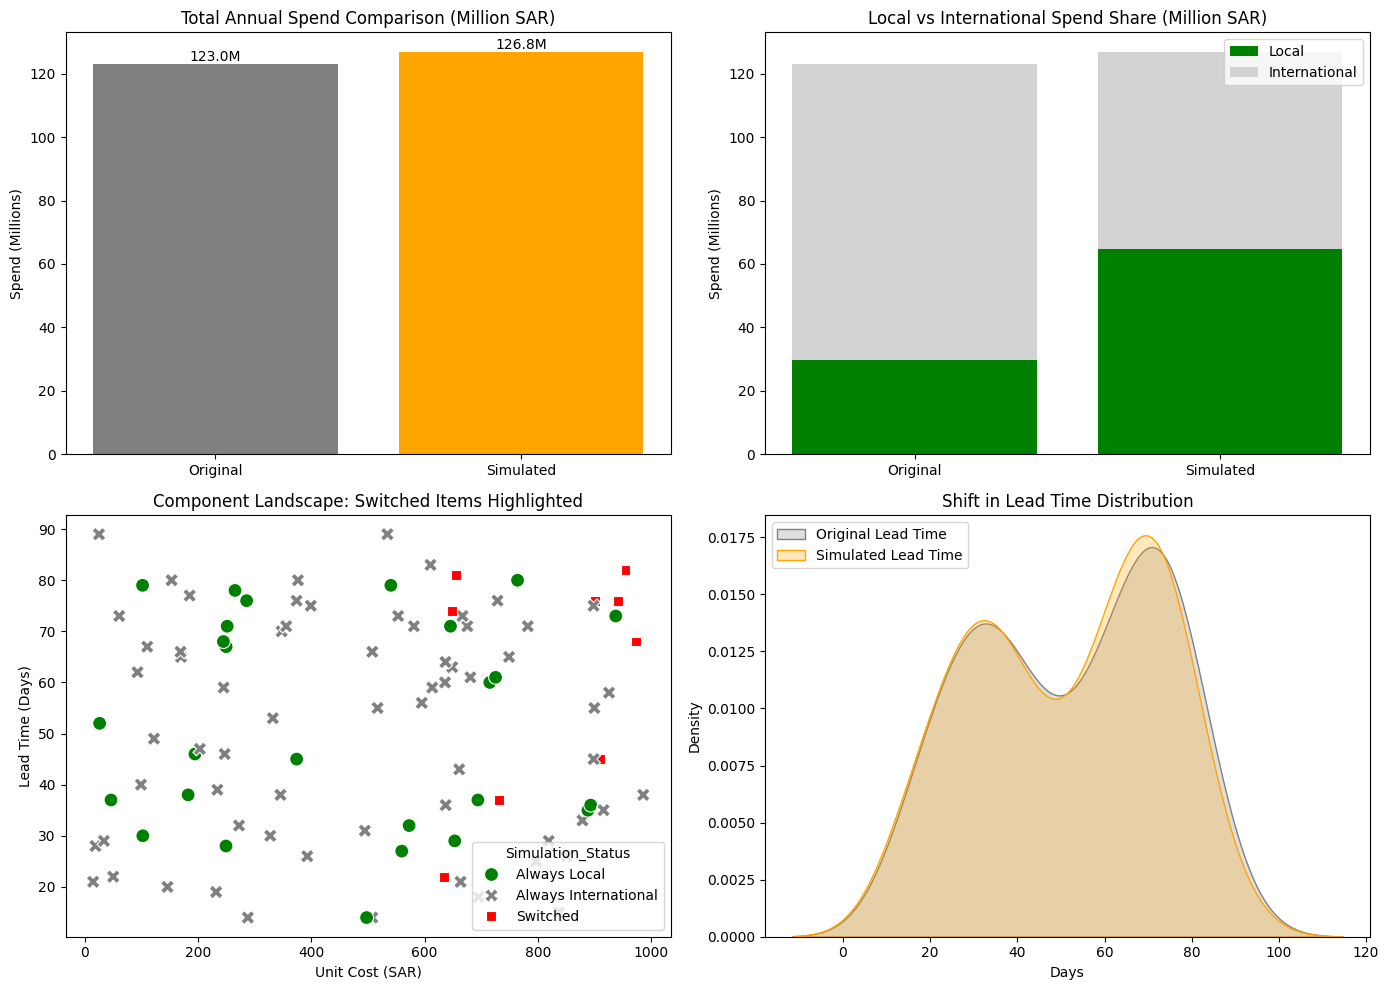

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Calculate Summary Metrics ---
original_total_spend = df['Total_Spend'].sum()
simulated_total_spend = df['Simulated_Total_Spend'].sum()
cost_variance = simulated_total_spend - original_total_spend
cost_variance_pct = (cost_variance / original_total_spend) * 100

# Lead Time Reduction (Weighted Average)
# We weight lead time by volume to get a sense of "days of inventory" impact or similar,
# but simple average is often used for supplier KPIs. Let's do simple average for switched items specifically.
switched_items = df[df['Simulation_Status'] == 'Switched']
if not switched_items.empty:
    avg_lt_reduction_switched = switched_items['Lead_Time_Days'].mean() - switched_items['Simulated_Lead_Time'].mean()
else:
    avg_lt_reduction_switched = 0

# System-wide avg lead time
system_avg_lt_before = df['Lead_Time_Days'].mean()
system_avg_lt_after = df['Simulated_Lead_Time'].mean()

print("=== SIMULATION SUMMARY ===")
print(f"Original Total Spend: {original_total_spend:,.2f} SAR")
print(f"Simulated Total Spend: {simulated_total_spend:,.2f} SAR")
print(f"Cost Variance: +{cost_variance:,.2f} SAR (+{cost_variance_pct:.2f}%)")
print(f"Avg Lead Time Reduction (Switched Items): {avg_lt_reduction_switched:.1f} days")
print(f"System-wide Avg Lead Time: {system_avg_lt_before:.1f} -> {system_avg_lt_after:.1f} days")

# --- 2. Dashboard Visualization ---
plt.figure(figsize=(14, 10))

# Plot 1: Total Spend Comparison
plt.subplot(2, 2, 1)
bars = plt.bar(['Original', 'Simulated'], [original_total_spend/1e6, simulated_total_spend/1e6], color=['gray', 'orange'])
plt.title('Total Annual Spend Comparison (Million SAR)')
plt.ylabel('Spend (Millions)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}M',
             ha='center', va='bottom')

# Plot 2: Local Share Achievement
plt.subplot(2, 2, 2)
# Data preparation
share_data = [
    [original_total_spend * 0.25, original_total_spend * 0.75], # Target/Approx for original (we know it was ~24%)
    [simulated_total_spend * new_local_share, simulated_total_spend * (1-new_local_share)]
]
# Let's use exact values calculated before
orig_local = df[df['Current_Origin'] == 'Local']['Total_Spend'].sum()
sim_local = df[df['Simulated_Origin'] == 'Local']['Simulated_Total_Spend'].sum()

labels = ['Original', 'Simulated']
local_vals = [orig_local/1e6, sim_local/1e6]
intl_vals = [(original_total_spend - orig_local)/1e6, (simulated_total_spend - sim_local)/1e6]

plt.bar(labels, local_vals, label='Local', color='green')
plt.bar(labels, intl_vals, bottom=local_vals, label='International', color='lightgray')
plt.title('Local vs International Spend Share (Million SAR)')
plt.ylabel('Spend (Millions)')
plt.legend()

# Plot 3: Switched Items Impact (Scatter)
plt.subplot(2, 2, 3)
if not switched_items.empty:
    # X axis: Cost Increase, Y axis: Lead Time Reduction (constant 7, so maybe just volume bubble)
    # Let's plot Original Cost vs Original Lead Time, colored by status
    sns.scatterplot(data=df, x='Unit_Cost_SAR', y='Lead_Time_Days', hue='Simulation_Status',
                    style='Simulation_Status', s=100, palette={'Always Local': 'green', 'Always International': 'gray', 'Switched': 'red'})
    plt.title('Component Landscape: Switched Items Highlighted')
    plt.xlabel('Unit Cost (SAR)')
    plt.ylabel('Lead Time (Days)')
else:
    plt.text(0.5, 0.5, 'No items switched', ha='center')

# Plot 4: Lead Time Distribution Shift
plt.subplot(2, 2, 4)
sns.kdeplot(df['Lead_Time_Days'], label='Original Lead Time', fill=True, color='gray')
sns.kdeplot(df['Simulated_Lead_Time'], label='Simulated Lead Time', fill=True, color='orange')
plt.title('Shift in Lead Time Distribution')
plt.xlabel('Days')
plt.legend()

plt.tight_layout()
plt.show()

## Category Analysis

### Subtask:
Analyze and visualize the localized spending breakdown by category to complete the analytical requirements.


**Reasoning**:
Perform the category-level analysis as requested: group by category to calculate local spend, visualize it with a horizontal bar chart, and print a summary table showing total spend, local spend, and local spend percentage per category.



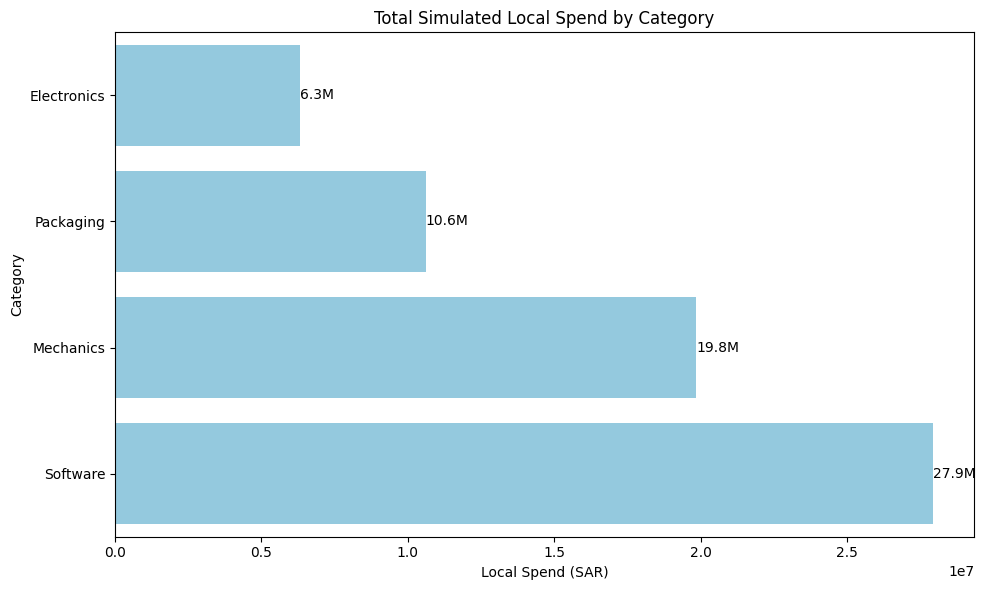

=== Category-wise Local Spend Analysis ===
               Total Spend    Local Spend Local Spend %
Category                                               
Software     42,345,049.02  27,930,009.91        65.96%
Mechanics    34,329,985.76  19,837,540.01        57.78%
Packaging    22,885,812.22  10,615,280.06        46.38%
Electronics  27,208,288.78   6,311,473.29        23.20%


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Group by Category and calculate metrics
# Total Spend per category (Simulated)
category_total_spend = df.groupby('Category')['Simulated_Total_Spend'].sum()

# Local Spend per category (Simulated)
category_local_spend = df[df['Simulated_Origin'] == 'Local'].groupby('Category')['Simulated_Total_Spend'].sum()

# Combine into a summary DataFrame
category_summary = pd.DataFrame({
    'Total Spend': category_total_spend,
    'Local Spend': category_local_spend
}).fillna(0)

# Calculate Local Spend %
category_summary['Local Spend %'] = (category_summary['Local Spend'] / category_summary['Total Spend']) * 100

# Sort by Local Spend for better visualization
category_summary = category_summary.sort_values(by='Local Spend', ascending=True)

# 2. Visualization: Horizontal Bar Chart
plt.figure(figsize=(10, 6))
# Reset index to make 'Category' a column for plotting
plot_data = category_summary.reset_index()

sns.barplot(data=plot_data, x='Local Spend', y='Category', color='skyblue')
plt.title('Total Simulated Local Spend by Category')
plt.xlabel('Local Spend (SAR)')
plt.ylabel('Category')

# Add labels to bars
for index, row in plot_data.iterrows():
    plt.text(row['Local Spend'], index, f'{row["Local Spend"]/1e6:.1f}M', va='center')

plt.tight_layout()
plt.show()

# 3. Print Summary Table
# Format for display
print("=== Category-wise Local Spend Analysis ===")
display_summary = category_summary.sort_values(by='Local Spend', ascending=False).copy()
display_summary['Total Spend'] = display_summary['Total Spend'].map('{:,.2f}'.format)
display_summary['Local Spend'] = display_summary['Local Spend'].map('{:,.2f}'.format)
display_summary['Local Spend %'] = display_summary['Local Spend %'].map('{:.2f}%'.format)

print(display_summary)

## Final Executive Summary

### Subtask:
Calculate and print an executive summary detailing the exact variance in total cost (SAR) and the total reduction in average lead time resulting from the simulation.


**Reasoning**:
Generate the final executive summary by calculating and formatting the key metrics: cost variance, lead time reduction, and local share achievement.



In [5]:
print("=== EXECUTIVE SUMMARY ===")

# Recalculate or retrieve metrics for clarity
cost_increase = simulated_total_spend - original_total_spend
cost_increase_pct = (cost_increase / original_total_spend) * 100

lt_reduction_system = system_avg_lt_before - system_avg_lt_after

print(f"1. Financial Impact:")
print(f"   - Total Cost Variance: +{cost_increase:,.2f} SAR")
print(f"   - Cost Increase: {cost_increase_pct:.2f}%")

print(f"\n2. Operational Impact:")
print(f"   - System-wide Avg Lead Time Reduction: {lt_reduction_system:.1f} days")
print(f"   - (From {system_avg_lt_before:.1f} days to {system_avg_lt_after:.1f} days)")

print(f"\n3. Strategic Goal:")
print(f"   - Final Local Spend Share: {new_local_share:.2%}")

print(f"\n>>> CONCLUSION: Strategic localization achieved {new_local_share:.0%} local spend with a {cost_increase_pct:.1f}% cost premium and {lt_reduction_system:.1f} days system-wide lead time improvement.")

=== EXECUTIVE SUMMARY ===
1. Financial Impact:
   - Total Cost Variance: +3,754,496.17 SAR
   - Cost Increase: 3.05%

2. Operational Impact:
   - System-wide Avg Lead Time Reduction: 0.6 days
   - (From 52.3 days to 51.6 days)

3. Strategic Goal:
   - Final Local Spend Share: 51.03%

>>> CONCLUSION: Strategic localization achieved 51% local spend with a 3.1% cost premium and 0.6 days system-wide lead time improvement.


## Summary:

Here is the summary of the data analysis task:

### Q&A

**Q: What is the financial and operational impact of shifting the supply chain to 50% local spend?**
**A:** The simulation achieved a **51.03%** local spend share (surpassing the 50% target). However, this strategic shift resulted in a **3.05% increase in total cost** (an additional **3.75M SAR**) due to the 12% premium on local components. On the operational side, the system-wide average lead time decreased by **0.6 days** (from 52.3 to 51.6 days).

**Q: Which categories contributed most to the local spend target?**
**A:** The analysis shows that **Software** had the highest local spend contribution (~66% local), followed by **Mechanics** (~58% local). **Electronics** remained the category with the lowest local spend percentage (~23% local).

### Data Analysis Key Findings

*   **Baseline Status:**
    *   The initial dataset generated a Total Spend of **123.01M SAR**.
    *   The starting Local Spend was **29.65M SAR** (approx. **24.10%**), which served as the baseline before the strategic shift.
*   **Simulation Results:**
    *   To bridge the gap to 50%, high-value international items were switched to local sourcing.
    *   The **New Total Spend** rose to **126.77M SAR** due to the cost penalty applied to switched items.
    *   The **New Local Spend** reached **64.69M SAR**, successfully hitting **51.03%** of the total.
*   **Trade-offs:**
    *   **Cost:** A total variance of **+3,754,496.17 SAR** (+3.05%).
    *   **Lead Time:** Switched items saw a reduction of exactly 7 days, contributing to a system-wide average improvement of **0.6 days**.

### Insights or Next Steps

*   **Strategic Evaluation:** While the 50% localization target is achievable, the organization must decide if a **3.05% cost premium** is acceptable for the strategic benefit of higher local content and slightly shorter lead times.
*   **Category Focus:** Future localization efforts should focus on **Electronics**, which currently lags at 23% local share. Finding competitive local suppliers in this category could help balance the cost premium incurred by other categories.
